# AU Mic b no SPARC4 — análise dos trânsitos

A fotometria já vem pronta nos produtos `*_lc.fits` do pipeline: magnitude de
abertura de **todas** as fontes do campo, em todos os instantes, nos quatro
canais. Este notebook não refaz redução — ele monta a curva **diferencial** a
partir dessa fotometria e ajusta o trânsito de AU Mic b.

## Organização

| célula | o que faz |
|:--:|---|
| 1 | **configuração** — tudo que se ajusta está aqui |
| 2 | leitura dos produtos do pipeline |
| 3 | curva diferencial: alvo / soma das comparações, limpeza, binning |
| 4 | modelo de trânsito (`batman`) |
| 5 | ajuste: linha de base + profundidade num só sistema linear, varredura em Tc |
| 6 | `analisa_noite()` — junta 3–5 numa função; `resumo()` imprime |
| 7 | figuras |
| 8 | quais noites têm trânsito |
| 9 | análise noite a noite |
| 10 | profundidade com Tc **preso** na efeméride — a medida limpa |
| 11 | as noites lado a lado e o O-C |
| 12 | arquivos gravados |

## Efeméride adotada

A época zero é o **Tc medido no próprio trânsito** de época 0 (`tc_000` do
ajuste, prior uniforme):

    Tc(E=0) = 2458330.380763 BJD_TDB  ±0.000205 d (~0.30 min)
            = 8330.380763 em BJD-2450000
            = 1330.380763 BTJD

com P = 8.4631566 d. Isso adianta o Tc previsto em **8.1 min** em relação à
efeméride anterior (2458330.3864186), em todas as épocas — o deslocamento é
constante porque só a época zero mudou, não o período.

## O que é medida e o que não é

A **profundidade com o Tc preso na efeméride** (célula 10) é o número a comparar
com a literatura. O **Tc livre não é mensurável** nestas noites: com linha de
base livre, um deslocamento de dezenas de minutos é absorvido pelo polinômio e o
ajuste passa a seguir a variabilidade da estrela. O O-C aparece só como
diagnóstico, e não significa nada onde a profundidade sai compatível com zero.

In [16]:
# ═══ 1 · configuração ═══════════════════════════════════════════════════════
# Tudo que se ajusta está nesta célula; as seguintes só consomem estes valores.
import os

BASE    = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
DATADIR = os.path.join(BASE, "data")
OUTDIR  = os.path.join(BASE, "resultados_transitos")
os.makedirs(OUTDIR, exist_ok=True)

# ── instrumento ─────────────────────────────────────────────────────────────
CANAIS = [1, 2, 3, 4]
BANDAS = {1: "g", 2: "r", 3: "i", 4: "z"}
CORES  = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

BEAM   = "S+N"     # soma dos dois feixes: cancela a modulação da lâmina
APER   = 8         # raio da abertura, em pixels (tem que existir no produto)
NCOMPS = 3         # nº de comparações: as mais brilhantes depois do alvo
COMPS  = {}        # força as comparações de um canal, p.ex. {1: [1, 3, 2]}

# ── planeta: AU Mic b ───────────────────────────────────────────────────────
# Época zero = Tc MEDIDO no trânsito de época 0 (tc_000 do ajuste, prior
# uniforme): 2458330.380763 BJD_TDB, ou 8330.380763 em BJD-2450000.
# O período continua o do MCMC próprio dos setores 1, 27 e 95
# (mcmc_auMic_b_ephx1.npz). Geometria de Plavchan+2020 / Martioli+2021.
T0_TDB  = 2458330.380763    # BJD_TDB medido (= 8330.380763 em BJD-2450000)
T0_ERR  = 0.000205          # d (~0.30 min); assimétrico -0.000200/+0.000205
PER     = 8.4631566         # d
PER_ERR = 0.0000050         # d (~0.4 s)

RP_RS  = 0.0496    # Rp/R*
A_RS   = 19.1      # a/R*
INC    = 89.5      # graus
ECC, W = 0.0, 90.0

# escurecimento de bordo quadrático por banda (Teff 3700 K, logg 4.5),
# valores aproximados das tabelas de Claret para o sistema SDSS
LDC = {"g": [0.62, 0.28], "r": [0.55, 0.32],
       "i": [0.40, 0.33], "z": [0.30, 0.32]}

# ── preparo da curva ────────────────────────────────────────────────────────
BIN_MIN    = 5.0    # binning padrão, em minutos
AMOSTRAGEM = {      # exceções por noite; None = cadência original, sem binning
    "20260822": None,
}
NSIG_OUT   = 4.0    # corte de outliers, para os DOIS lados (flare sobe, nuvem desce)
JANELA_MIN = 10.0   # janela da mediana móvel que serve de referência ao corte
MIN_FRAC   = 0.3    # descarta bins com menos que isto da mediana de exposições
BIN_VIS_MIN = 1.5   # binning SÓ para a figura, quando a curva não foi binada

# ── ajuste ──────────────────────────────────────────────────────────────────
BASE_ORD  = 1       # ordem do polinômio no tempo (1 = reta)
USA_MASSA = True    # inclui termo linear em (massa de ar - 1)
DT_MAX    = 15.0    # semi-largura da varredura em Tc, em minutos
PASSO_TC  = 0.5     # passo da varredura, em minutos

print(f"dados:      {DATADIR}")
print(f"resultados: {OUTDIR}")
print(f"AU Mic b:   Tc(E=0) = {T0_TDB} BJD_TDB (= {T0_TDB - 2450000:.6f} em "
      f"BJD-2450000) ± {T0_ERR*1440:.2f} min")
print(f"            P = {PER} d | Rp/R* = {RP_RS}  ->  profundidade geométrica "
      f"{RP_RS**2*1e3:.2f} ppt (sem escurecimento de bordo)")

dados:      C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\data
resultados: C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\resultados_transitos
AU Mic b:   Tc(E=0) = 2458330.380763 BJD_TDB (= 8330.380763 em BJD-2450000) ± 0.30 min
            P = 8.4631566 d | Rp/R* = 0.0496  ->  profundidade geométrica 2.46 ppt (sem escurecimento de bordo)


In [17]:
# ═══ 2 · leitura dos produtos do pipeline ═══════════════════════════════════
# O produto *_lc.fits traz uma extensão CATALOG_PHOT_APxxx por raio de abertura,
# com uma linha por (fonte, instante). Aqui isso vira uma matriz (fonte, tempo).
import glob
import numpy as np
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
import astropy.units as u


def caminho_lc(noite, ch):
    """Produto de fotometria da noite/canal (o do feixe BEAM)."""
    padrao = os.path.join(DATADIR, noite, f"*_s4c{ch}_*_{BEAM}_lc.fits")
    arqs = sorted(glob.glob(padrao))
    if not arqs:
        raise FileNotFoundError(f"nenhum produto casa com {padrao}")
    return arqs[0]


def cabecalho(noite, ch=1):
    """Cabeçalho primário — TSTART/TSTOP, coordenadas, sítio."""
    return fits.getheader(caminho_lc(noite, ch))


def le_fotometria(noite, ch, aper=APER):
    """Fotometria pronta do pipeline, já organizada.

    Devolve (hdr, t_utc, idx, MAG, EMAG), com MAG e EMAG na forma
    (fonte, tempo) e NaN onde o pipeline levantou FLAG.
    """
    with fits.open(caminho_lc(noite, ch)) as h:
        exts = [e for e in h[1:] if e.header.get("APRADIUS") == aper]
        if not exts:
            disp = sorted({e.header.get("APRADIUS") for e in h[1:]})
            raise KeyError(f"abertura {aper} px não existe; há {disp}")
        d, hdr = exts[0].data, h[0].header
        src  = np.asarray(d["SRCINDEX"], float).astype(int)
        t    = np.asarray(d["TIME"], float)
        mag  = np.asarray(d["MAG"], float)
        emag = np.asarray(d["EMAG"], float)
        flag = np.asarray(d["FLAG"]) if "FLAG" in d.columns.names else None

    idx, t_utc = np.unique(src), np.unique(t)
    lin, col = np.searchsorted(idx, src), np.searchsorted(t_utc, t)
    M = np.full((idx.size, t_utc.size), np.nan)
    E = np.full_like(M, np.nan)
    M[lin, col], E[lin, col] = mag, emag
    if flag is not None:
        ruim = np.zeros(M.shape, bool)
        ruim[lin, col] = np.asarray(flag) != 0
        M[ruim] = np.nan
    return hdr, t_utc, idx, M, E


def massa_de_ar(t_utc, hdr):
    """sec(z) do alvo, do sítio e das coordenadas gravadas no cabeçalho."""
    sitio = EarthLocation(lat=hdr["OBSLAT"] * u.deg, lon=hdr["OBSLONG"] * u.deg,
                          height=hdr["OBSALT"] * u.m)
    alvo  = SkyCoord(hdr["RA"] * u.deg, hdr["DEC"] * u.deg, frame="icrs")
    tempo = Time(t_utc, format="jd", scale="utc")
    return alvo.transform_to(AltAz(obstime=tempo, location=sitio)).secz.value


def rotulo_noite(noite):
    return f"{noite[:4]}-{noite[4:6]}-{noite[6:]}"


def noites_disponiveis():
    """Noites com produto nos quatro canais."""
    saida = []
    for d in sorted(glob.glob(os.path.join(DATADIR, "*", ""))):
        noite = os.path.basename(os.path.normpath(d))
        if all(glob.glob(os.path.join(d, f"*_s4c{ch}_*_{BEAM}_lc.fits"))
               for ch in CANAIS):
            saida.append(noite)
    return saida


print("noites com os quatro canais:", ", ".join(noites_disponiveis()))

noites com os quatro canais: 20260702, 20260713, 20260714, 20260719, 20260731, 20260803, 20260805, 20260815, 20260818, 20260822


In [18]:
# ═══ 3 · curva diferencial ══════════════════════════════════════════════════
# alvo / soma das comparações, tempo em BJD_TDB, outliers cortados, binado.
from scipy.ndimage import median_filter


def curva_diferencial(noite, ch, aper=APER, ncomps=NCOMPS, comps=None):
    """Razão de fluxos alvo / Σ comparações, a partir da fotometria do pipeline.

    O alvo é a fonte mais brilhante do campo e as comparações são as `ncomps`
    seguintes, a não ser que `comps` traga índices explícitos.
    """
    hdr, t_utc, idx, M, E = le_fotometria(noite, ch, aper)

    ordem = idx[np.argsort(np.nanmedian(M, axis=1))]
    alvo  = int(ordem[0])
    comps = [int(c) for c in (comps if comps else ordem[1:1 + ncomps])]
    ia = int(np.where(idx == alvo)[0][0])
    ic = [int(np.where(idx == c)[0][0]) for c in comps]

    with np.errstate(invalid="ignore", divide="ignore"):
        f_alvo = 10 ** (-0.4 * M[ia])
        f_comp = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
        razao  = f_alvo / f_comp
        e_comp = np.sqrt(np.nansum((10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
        e_raz  = razao * 0.4 * np.log(10) * np.hypot(
            E[ia], e_comp / np.where(f_comp > 0, f_comp, np.nan))

    ok = np.isfinite(razao) & np.isfinite(e_raz)
    t_tdb = Time(t_utc[ok], format="jd", scale="utc").tdb.jd   # BJD_UTC -> BJD_TDB
    return dict(noite=noite, canal=ch, banda=BANDAS[ch], alvo=alvo, comps=comps,
                t=t_tdb, f=razao[ok] / np.nanmedian(razao[ok]), ef=e_raz[ok],
                X=massa_de_ar(t_utc[ok], hdr))


def mascara_boa(t, f, janela_min=JANELA_MIN, nsig=NSIG_OUT):
    """Corta outliers dos DOIS lados em torno de uma mediana móvel.

    Flare sobe, nuvem e frame com guiagem ruim DESCEM: um corte só positivo
    deixa passar quedas que imitam trânsito. Como a referência é a mediana
    móvel de `janela_min` (bem mais curta que T14), o corte não come o sinal.
    """
    n_jan = max(int(round((janela_min / 1440) / np.median(np.diff(t)))) | 1, 3)
    resid = f - median_filter(f, size=n_jan, mode="nearest")
    sigma = 1.4826 * np.median(np.abs(resid - np.median(resid)))
    return np.abs(resid) < nsig * sigma


def binar(t, f, ef, dt_min):
    """Média em janelas fixas. O erro do bin é a dispersão interna."""
    k = np.floor((t - t.min()) / (dt_min / 1440)).astype(int)
    tb, fb, eb, nb = [], [], [], []
    for g in np.unique(k):
        m = k == g
        tb.append(t[m].mean())
        fb.append(f[m].mean())
        eb.append(f[m].std(ddof=1) / np.sqrt(m.sum()) if m.sum() > 1 else ef[m][0])
        nb.append(int(m.sum()))
    return (np.array(tb), np.array(fb), np.array(eb), np.array(nb))


def prepara_noite(noite, bin_min=BIN_MIN, aper=APER, ncomps=NCOMPS,
                  nsig_out=NSIG_OUT, min_frac=MIN_FRAC, canais=None):
    """Curva pronta para o ajuste, canal a canal.

    `bin_min=None` desliga o binning: fica a cadência original do instrumento
    (e aí o modelo passa a ser integrado no tempo de exposição real).
    """
    dd = {}
    for ch in (canais or CANAIS):
        c   = curva_diferencial(noite, ch, aper, ncomps, COMPS.get(ch))
        bom = mascara_boa(c["t"], c["f"], nsig=nsig_out)

        if bin_min is None:
            tb, fb = c["t"][bom], c["f"][bom]
            # sem bin não há dispersão interna, e o EMAG formal do pipeline
            # superestima o ruído real; quem dá o erro é o piso logo abaixo.
            eb, nb, fora = np.zeros(tb.size), np.ones(tb.size, int), 0
        else:
            tb, fb, eb, nb = binar(c["t"][bom], c["f"][bom], c["ef"][bom], bin_min)
            cheio = nb >= min_frac * np.median(nb)   # bordas e falhas de guiagem
            tb, fb, eb, nb = tb[cheio], fb[cheio], eb[cheio], nb[cheio]
            fora = int((~cheio).sum())

        fb = fb / np.median(fb)
        # piso de erro: o ruído branco ponto a ponto medido na própria curva
        eb = np.maximum(eb, np.std(np.diff(fb)) / np.sqrt(2))

        dd[ch] = dict(c, tb=tb, fb=fb, eb=eb, nb=nb,
                      Xb=np.interp(tb, c["t"], c["X"]),
                      cortados=int((~bom).sum()), bins_fora=fora)
    return dd

In [19]:
# ═══ 4 · modelo de trânsito ═════════════════════════════════════════════════
# batman com a geometria da literatura fixa. O único parâmetro livre do modelo
# é uma ESCALA da profundidade (célula 5) — Rp/R*, a/R* e i não são ajustáveis
# com o sinal que uma noite isolada oferece.
import batman


def duracao_T14(rp=RP_RS, a=A_RS, inc=INC, per=PER):
    b = a * np.cos(np.radians(inc))
    return per / np.pi * np.arcsin(
        np.sqrt(max((1 + rp) ** 2 - b ** 2, 0.0)) / (a * np.sin(np.radians(inc))))


B_IMP = A_RS * np.cos(np.radians(INC))
T14   = duracao_T14()


def modelo_transito(t, tc, banda, exp_min):
    """Curva de luz normalizada, integrada em `exp_min` minutos."""
    p = batman.TransitParams()
    p.t0, p.per, p.rp, p.a, p.inc = tc, PER, RP_RS, A_RS, INC
    p.ecc, p.w = ECC, W
    p.u, p.limb_dark = list(LDC[banda]), "quadratic"
    m = batman.TransitModel(p, np.asarray(t, float),
                            supersample_factor=7, exp_time=exp_min / 1440)
    return m.light_curve(p)


def perfil(t, tc, banda, exp_min):
    """Perfil do trânsito: 0 fora, profundidade da literatura no centro."""
    return 1 - modelo_transito(t, tc, banda, exp_min)


def profundidade_literatura(tc, banda):
    """Profundidade no centro, com escurecimento de bordo e sem borrar o bin."""
    t = np.linspace(tc - T14, tc + T14, 2000)
    return float(np.max(perfil(t, tc, banda, 0.5)))


_p0 = {b: profundidade_literatura(T0_TDB, b) for b in BANDAS.values()}
print(f"AU Mic b:  T14 = {T14*24:.2f} h   |   parâmetro de impacto b = {B_IMP:.3f}")
print("profundidade esperada por banda (ppt): " +
      "  ".join(f"{b}' {p*1e3:.2f}" for b, p in _p0.items()))

AU Mic b:  T14 = 3.51 h   |   parâmetro de impacto b = 0.167
profundidade esperada por banda (ppt): g' 3.26  r' 3.20  i' 3.01  z' 2.89


In [21]:
# ═══ 5 · ajuste: linha de base + profundidade ═══════════════════════════════
# A linha de base de cada canal (polinômio no tempo + massa de ar) e UMA escala
# comum da profundidade entram num único sistema linear, resolvido de uma vez.
# Só o instante Tc é não-linear, e ele é varrido numa grade.


def matriz_base(d, tc0, base_ord=BASE_ORD, usa_massa=USA_MASSA):
    """Colunas da linha de base de um canal: 1, t, t², ..., (massa de ar - 1)."""
    tn = (d["tb"] - tc0) * 24
    cols = [np.ones_like(tn)] + [tn ** k for k in range(1, base_ord + 1)]
    if usa_massa:
        cols.append(d["Xb"] - 1)
    return np.column_stack(cols)


def resolve(dd, des, canais, tc, exp_min, com_transito=True):
    """Mínimos quadrados ponderados. -> (chi2, par, cov, ndof).

    `par` traz as linhas de base de cada canal em blocos e, se
    `com_transito`, a escala da profundidade no último elemento
    (1.0 = profundidade da literatura).
    """
    nb   = des[canais[0]].shape[1]
    n    = sum(dd[ch]["tb"].size for ch in canais)
    ncol = len(canais) * nb + (1 if com_transito else 0)
    G, y, w, i0 = np.zeros((n, ncol)), np.zeros(n), np.zeros(n), 0
    for j, ch in enumerate(canais):
        k, d = dd[ch]["tb"].size, dd[ch]
        sl = slice(i0, i0 + k)
        G[sl, j * nb:(j + 1) * nb] = des[ch]
        if com_transito:
            G[sl, -1] = -perfil(d["tb"], tc, d["banda"], exp_min)
        y[sl], w[sl] = d["fb"], 1 / d["eb"]
        i0 += k
    Gw, yw = G * w[:, None], y * w
    par, *_ = np.linalg.lstsq(Gw, yw, rcond=None)
    chi2 = float(np.sum((Gw @ par - yw) ** 2))
    return chi2, par, np.linalg.pinv(Gw.T @ Gw), n - ncol


def linhas_de_base(dd, des, canais, par):
    nb = des[canais[0]].shape[1]
    return {ch: des[ch] @ par[j * nb:(j + 1) * nb] for j, ch in enumerate(canais)}


def fator_beta(dd, bases, canais, tc, delta, exp_min, escala_min=20.0):
    """Ruído correlacionado (β de Winn+2008), medido em bins de `escala_min`.

    Só faz sentido quando a curva não foi binada: aí o erro de cada ponto é
    branco e, com dezenas de milhares de pontos, o erro da profundidade sairia
    absurdamente pequeno. O que limita a medida é o ruído em escalas de ~20 min
    (manchas, massa de ar, guiagem). β = quanto a dispersão dos resíduos
    binados excede o previsto pelo ruído branco.
    """
    bs = []
    for ch in canais:
        d = dd[ch]
        r = d["fb"] / bases[ch] - (1 - delta * perfil(d["tb"], tc, d["banda"], exp_min))
        g = np.floor((d["tb"] - d["tb"].min()) / (escala_min / 1440)).astype(int)
        grupos = np.unique(g)
        mb = np.array([r[g == gi].mean() for gi in grupos])
        nn = np.median([np.sum(g == gi) for gi in grupos])
        branco = np.std(r) / np.sqrt(nn) * np.sqrt(mb.size / max(mb.size - 1, 1))
        bs.append(max(float(np.std(mb) / branco), 1.0))
    return float(np.median(bs))

In [22]:
# ═══ 6 · uma noite, do produto ao resultado ═════════════════════════════════
# analisa_noite() calcula e devolve tudo num dicionário; resumo() imprime.
import pandas as pd


def analisa_noite(noite, bin_min="auto", tc_manual=None, dt_max=DT_MAX,
                  passo_tc=PASSO_TC, base_ord=BASE_ORD, usa_massa=USA_MASSA,
                  aper=APER, ncomps=NCOMPS, nsig_out=NSIG_OUT,
                  min_frac=MIN_FRAC, canais=None):
    """Fotometria diferencial -> previsão -> ajuste, para uma noite.

    `dt_max=0` prende o Tc na efeméride (ou em `tc_manual`): é assim que se
    mede a profundidade sem deixar o ajuste procurar o evento na noite inteira.
    """
    if bin_min == "auto":
        bin_min = AMOSTRAGEM.get(noite, BIN_MIN)

    dd = prepara_noite(noite, bin_min, aper, ncomps, nsig_out, min_frac, canais)
    cl = sorted(dd)
    bd = [dd[ch]["banda"] for ch in cl]
    t1 = min(d["t"].min() for d in dd.values())
    t2 = max(d["t"].max() for d in dd.values())

    # ── previsão da efeméride ───────────────────────────────────────────────
    epoca  = int(round((0.5 * (t1 + t2) - T0_TDB) / PER))
    tc_ef  = T0_TDB + epoca * PER
    tc_err = float(np.hypot(T0_ERR, epoca * PER_ERR))
    tc0    = float(tc_manual) if tc_manual is not None else tc_ef
    cobertura = max((min(t2, tc0 + T14 / 2) - max(t1, tc0 - T14 / 2)) / T14, 0.0)

    # tempo de integração que o modelo enxerga: o bin, ou a cadência real
    if bin_min is not None:
        exp_min = float(bin_min)
        rot_bin = f"bins de {bin_min:g} min"
    else:
        exp_min = float(np.median([np.median(np.diff(dd[ch]["tb"])) for ch in cl]) * 1440)
        rot_bin = f"cadência original (~{exp_min*60:.1f} s por ponto)"

    prof0 = {b: profundidade_literatura(tc0, b) for b in bd}
    des   = {ch: matriz_base(dd[ch], tc0, base_ord, usa_massa) for ch in cl}

    # ── varredura em Tc ─────────────────────────────────────────────────────
    grade  = tc0 + np.arange(-dt_max, dt_max + 1e-9, passo_tc) / 1440
    saidas = [resolve(dd, des, cl, tc, exp_min) for tc in grade]
    chi2s  = np.array([s[0] for s in saidas])
    deltas = np.array([s[1][-1] for s in saidas])
    i_min  = int(np.argmin(chi2s))
    tc_fit = float(grade[i_min])
    no_limite = bool(dt_max > 2 and i_min in (0, grade.size - 1))

    chi2, par, cov, ndof = saidas[i_min]
    escala  = max(chi2 / ndof, 1.0)      # infla erros se o χ² reduzido passar de 1
    delta   = float(par[-1])
    e_delta = float(np.sqrt(abs(cov[-1, -1]) * escala))
    bases   = linhas_de_base(dd, des, cl, par)
    dchi2   = (resolve(dd, des, cl, tc_fit, exp_min, com_transito=False)[0] - chi2) / escala

    # sem binning o erro por ponto é branco: corrige pelo ruído correlacionado
    beta = 1.0
    if bin_min is None:
        beta = fator_beta(dd, bases, cl, tc_fit, delta, exp_min)
        e_delta *= beta
        dchi2   /= beta ** 2
    nsig = float(np.sign(delta) * np.sqrt(max(dchi2, 0.0)))

    # ── a mesma profundidade, banda a banda ─────────────────────────────────
    por_banda = []
    for ch in cl:
        c2, p1, cv, nd = resolve(dd, des, [ch], tc_fit, exp_min)
        e1 = float(np.sqrt(abs(cv[-1, -1]) * max(c2 / nd, 1.0))) * beta
        por_banda.append({
            "banda": f"{dd[ch]['banda']}'",
            "prof (ppt)": p1[-1] * prof0[dd[ch]["banda"]] * 1e3,
            "sigma (ppt)": e1 * prof0[dd[ch]["banda"]] * 1e3,
            "esperada (ppt)": prof0[dd[ch]["banda"]] * 1e3,
            "rms resíduo (ppt)": np.std(
                dd[ch]["fb"] / bases[ch]
                - (1 - delta * perfil(dd[ch]["tb"], tc_fit, dd[ch]["banda"], exp_min))) * 1e3,
            "n pontos": int(dd[ch]["tb"].size),
        })
    tab_bandas = pd.DataFrame(por_banda).set_index("banda")

    return dict(
        noite=noite, rotulo=rotulo_noite(noite), epoca=epoca,
        t1=t1, t2=t2, canais=cl, bandas=bd, dados=dd, bases=bases,
        bin_min=bin_min, exp_min=exp_min, rot_bin=rot_bin,
        tc_efem=tc_ef, tc_err=tc_err, tc0=tc0, tc_fit=tc_fit,
        oc_min=(tc_fit - tc_ef) * 1440, cobertura=cobertura, tc_livre=dt_max > 0,
        no_limite=no_limite, dt_max=dt_max, grade=grade, chi2s=chi2s, deltas=deltas,
        delta=delta, e_delta=e_delta, prof0=prof0, prof_ppt=delta * prof0[bd[0]] * 1e3,
        sig_ppt=e_delta * prof0[bd[0]] * 1e3, dchi2=dchi2, nsig=nsig,
        chi2r=chi2 / ndof, escala=escala, beta=beta, ndof=ndof,
        tab_bandas=tab_bandas,
        perfil=lambda t, tc, b, _e=exp_min: perfil(t, tc, b, _e),
    )


def resumo(r):
    """Imprime o resultado de uma noite, com os avisos que ele exige."""
    b0 = r["bandas"][0]
    print(f"── {r['rotulo']} · época {r['epoca']} " + "─" * 44)
    print(f"janela      {r['t1']:.5f} .. {r['t2']:.5f} BJD_TDB  "
          f"({(r['t2']-r['t1'])*24:.1f} h) | cobertura de T14: {r['cobertura']*100:.0f} %")
    print(f"Tc previsto {r['tc_efem']:.5f}  "
          f"({Time(r['tc_efem'], format='jd').isot[11:19]} UTC ± {r['tc_err']*1440:.1f} min)")
    if r["tc_livre"]:
        print(f"Tc ajustado {r['tc_fit']:.5f}  |  O-C = {r['oc_min']:+.1f} min "
              f"(varredura ± {r['dt_max']:.0f} min)")
    else:
        print("Tc          preso na efeméride")
    print(f"profundidade {r['prof_ppt']:+.2f} ± {r['sig_ppt']:.2f} ppt em {b0}'  "
          f"(literatura {r['prof0'][b0]*1e3:.2f})  ->  {r['nsig']:+.1f}σ")
    print(f"amostragem  {r['rot_bin']} | "
          f"{sum(r['dados'][c]['tb'].size for c in r['canais'])} pontos | "
          f"χ²/ndof = {r['chi2r']:.2f}"
          + (f" | β = {r['beta']:.1f}" if r["beta"] != 1 else ""))
    print("cortados / bins descartados: " +
          " | ".join(f"{r['dados'][c]['banda']}': {r['dados'][c]['cortados']}"
                     f"/{r['dados'][c]['bins_fora']}" for c in r["canais"]))
    if r["no_limite"]:
        print(f"AVISO: o Tc encostou no limite da varredura (± {r['dt_max']:.0f} min) — "
              "o ajuste está seguindo a\n       variabilidade da estrela, não o "
              "trânsito; não leia esse O-C como medida.")
    if r["nsig"] < 3:
        print("AVISO: profundidade compatível com zero (ou negativa): sem detecção "
              "nesta noite.")

In [23]:
# ═══ 7 · figuras ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

DESLOC = 0.012   # deslocamento vertical entre bandas, no painel de cima


def pontos_figura(r, ch):
    """Pontos de um canal prontos para plotar.

    Se a noite foi ajustada na cadência original, são dezenas de milhares de
    pontos e o trânsito some no ruído: aqui eles são binados em BIN_VIS_MIN
    SÓ para a figura — o ajuste continua sendo o da cadência cheia.
    Devolve (t, fluxo, erro, linha de base, estilo do marcador).
    """
    d = r["dados"][ch]
    if r["bin_min"] is not None or not BIN_VIS_MIN:
        return d["tb"], d["fb"], d["eb"], r["bases"][ch], (5, .6, .8)
    tb, fb, eb, _ = binar(d["tb"], d["fb"], d["eb"], BIN_VIS_MIN)
    return tb, fb, eb, np.interp(tb, d["tb"], r["bases"][ch]), (3.5, .5, .75)


def _rot_amostragem(r):
    if r["bin_min"] is not None or not BIN_VIS_MIN:
        return r["rot_bin"]
    return f"{r['rot_bin']}, figura binada em {BIN_VIS_MIN:g} min"


def plota_noite(r, titulo=None):
    """Curvas com a linha de base ajustada e, embaixo, a curva já corrigida."""
    tg = np.linspace(r["t1"], r["t2"], 1200)
    fig, axs = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True,
                            gridspec_kw=dict(height_ratios=[1.1, 1.4]))
    for j, ch in enumerate(r["canais"]):
        b = r["bandas"][j]
        t, f, e, base, (ms, lw, al) = pontos_figura(r, ch)
        x = (t - r["tc_fit"]) * 24
        axs[0].errorbar(x, f + j * DESLOC, e, fmt=".", ms=ms, lw=lw, alpha=al,
                        color=CORES[b], label=f"{b}' (+{j*DESLOC*1e3:.0f} ppt)")
        axs[0].plot(x, base - r["delta"] * r["perfil"](t, r["tc_fit"], b) + j * DESLOC,
                    "-", lw=1.3, color="k", alpha=.7)
        axs[1].errorbar(x, f / base, e, fmt=".", ms=ms, lw=lw, alpha=al,
                        color=CORES[b], label=f"{b}'")

    b0 = r["bandas"][0]
    axs[1].plot((tg - r["tc_fit"]) * 24, 1 - r["delta"] * r["perfil"](tg, r["tc_fit"], b0),
                "-", lw=2, color="crimson",
                label=f"ajuste: {r['prof_ppt']:+.2f} ± {r['sig_ppt']:.2f} ppt "
                      f"({r['nsig']:+.1f}σ)")
    axs[1].plot((tg - r["tc_fit"]) * 24, 1 - r["perfil"](tg, r["tc_fit"], b0),
                "--", lw=1.3, color="steelblue",
                label=f"literatura: {r['prof0'][b0]*1e3:.2f} ppt")
    for ax in axs:
        ax.axvline(-T14 / 2 * 24, color="0.6", lw=.8, ls="--")
        ax.axvline(+T14 / 2 * 24, color="0.6", lw=.8, ls="--")
        ax.axvline(0, color="0.6", lw=.8, ls=":")
    axs[0].set_ylabel("fluxo diferencial (deslocado)")
    axs[0].legend(ncol=4, fontsize=9)
    axs[0].set_title(titulo or
                     f"AU Mic b · {r['rotulo']} · época {r['epoca']} · "
                     f"cobertura {r['cobertura']*100:.0f} % · {_rot_amostragem(r)}")
    axs[1].set_ylabel("fluxo / linha de base")
    axs[1].set_xlabel(f"horas desde Tc {'ajustado' if r['tc_livre'] else 'previsto'}")
    axs[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()


def plota_varredura(r):
    """Onde a noite aceitaria um trânsito, e de que profundidade."""
    if r["grade"].size < 3:
        return
    b0 = r["bandas"][0]
    hg = (r["grade"] - r["tc_efem"]) * 1440
    fig, ax = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
    ax[0].plot(hg, (r["chi2s"] - r["chi2s"].min()) / r["escala"], "-", lw=1.3, color="#333")
    ax[0].axhline(0, color="0.6", lw=.7)
    ax[0].set_ylabel("Δχ² (0 = melhor)")
    ax[0].set_title(f"{r['rotulo']} · varredura do instante do trânsito "
                    "(profundidade negativa = clareamento, não trânsito)")
    ax[1].plot(hg, r["deltas"] * r["prof0"][b0] * 1e3, "-", lw=1.3, color="#333")
    ax[1].axhline(0, color="0.6", lw=.7)
    ax[1].axhline(r["prof0"][b0] * 1e3, color="steelblue", ls="--", lw=1,
                  label="literatura")
    ax[1].axvspan(-r["tc_err"] * 1440, r["tc_err"] * 1440, color="orange", alpha=.15)
    ax[1].axvline(0, color="orange", lw=1.2, label="efeméride")
    ax[1].axvline(r["oc_min"], color="crimson", lw=1.2, label="melhor Tc")
    ax[1].set_ylabel("profundidade (ppt)")
    ax[1].set_xlabel("Tc testado — minutos desde a efeméride")
    ax[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()


def plota_noites(lista, titulo="AU Mic b · noites alinhadas pelo Tc da efeméride"):
    """Uma linha por noite, alinhadas pelo Tc previsto, na banda mais limpa."""
    fig, axs = plt.subplots(len(lista), 1, figsize=(11, 3.1 * len(lista)), sharex=True)
    axs = np.atleast_1d(axs)
    for ax, r in zip(axs, lista):
        ch, b = r["canais"][0], r["bandas"][0]
        t, f, e, base, (ms, lw, al) = pontos_figura(r, ch)
        ax.errorbar((t - r["tc_efem"]) * 24, f / base, e, fmt=".", ms=ms, lw=lw,
                    alpha=al, color=CORES[b])
        tg = np.linspace(r["t1"], r["t2"], 800)
        ax.plot((tg - r["tc_efem"]) * 24, 1 - r["perfil"](tg, r["tc_fit"], b),
                "--", lw=1.2, color="steelblue", label="literatura")
        ax.plot((tg - r["tc_efem"]) * 24,
                1 - r["delta"] * r["perfil"](tg, r["tc_fit"], b),
                "-", lw=1.6, color="crimson",
                label=f"ajuste: {r['prof_ppt']:+.2f} ppt ({r['nsig']:+.1f}σ)")
        ax.axvline(0, color="0.6", lw=.8, ls=":")
        ax.axvline(-T14 / 2 * 24, color="0.6", lw=.8, ls="--")
        ax.axvline(+T14 / 2 * 24, color="0.6", lw=.8, ls="--")
        ax.set_ylabel(f"{r['rotulo']}\n{b}'")
        ax.legend(fontsize=8, loc="lower left")
    axs[0].set_title(titulo)
    axs[-1].set_xlabel("horas desde o Tc previsto")
    plt.tight_layout(); plt.show()


def plota_oc(lista):
    """O-C das épocas. Noite sem detecção entra aberta: o Tc dela não é medida."""
    plt.figure(figsize=(8, 3.6))
    for r in lista:
        det = r["nsig"] >= 3
        plt.errorbar(r["epoca"], r["oc_min"], r["tc_err"] * 1440, fmt="o", ms=8, lw=1,
                     markerfacecolor="#333" if det else "white",
                     markeredgecolor="#333", ecolor="#888")
    plt.axhline(0, color="crimson", lw=1.2, label="efeméride")
    plt.xlabel("época"); plt.ylabel("O-C (min)")
    plt.title("AU Mic b · O-C das noites do SPARC4 (símbolo aberto = sem detecção)")
    plt.legend(); plt.tight_layout(); plt.show()

In [24]:
# ═══ 8 · quais noites têm trânsito ══════════════════════════════════════════
# Só pelo cabeçalho (TSTART/TSTOP), sem abrir a fotometria: para cada noite,
# a época mais próxima e quanto de T14 cai dentro da janela observada.

def inventario(noites=None):
    linhas = []
    for noite in (noites or noites_disponiveis()):
        h = cabecalho(noite)
        t1, t2 = h["TSTART"], h["TSTOP"]
        epoca = int(round((0.5 * (t1 + t2) - T0_TDB) / PER))
        tc    = T0_TDB + epoca * PER
        cob   = max((min(t2, tc + T14 / 2) - max(t1, tc - T14 / 2)) / T14, 0.0)
        linhas.append(dict(
            noite=rotulo_noite(noite), pasta=noite,
            início=Time(t1, format="jd").isot[11:16],
            fim=Time(t2, format="jd").isot[11:16],
            duração_h=(t2 - t1) * 24, época=epoca,
            Tc_previsto=Time(tc, format="jd").isot[:16].replace("T", " "),
            cobertura_pct=cob * 100))
    return pd.DataFrame(linhas).set_index("noite")


INVENTARIO = inventario()
display(INVENTARIO.style.format({"duração_h": "{:.2f}", "cobertura_pct": "{:.0f}"}))

NOITES_TRANSITO = list(INVENTARIO.loc[INVENTARIO["cobertura_pct"] > 0, "pasta"])
print(f"{len(NOITES_TRANSITO)} noites com trânsito de AU Mic b na janela: "
      + ", ".join(rotulo_noite(n) for n in NOITES_TRANSITO))
print("amostragem: " + " | ".join(
    f"{rotulo_noite(n)}: " +
    (f"bins de {AMOSTRAGEM.get(n, BIN_MIN):g} min" if AMOSTRAGEM.get(n, BIN_MIN)
     else "cadência original") for n in NOITES_TRANSITO))

,pasta,início,fim,duração_h,época,Tc_previsto,cobertura_pct
noite,,,,,,,
2026-07-02,20260702,01:41,08:39,6.97,342,2026-07-03 06:43,100
2026-07-13,20260713,01:14,04:52,3.63,343,2026-07-11 17:50,0
2026-07-14,20260714,02:11,08:25,6.23,343,2026-07-11 17:50,0
2026-07-19,20260719,00:56,06:28,5.54,344,2026-07-20 04:57,93
2026-07-31,20260731,23:28,07:46,8.31,345,2026-07-28 16:04,0
2026-08-03,20260803,00:32,07:41,7.14,346,2026-08-06 03:11,0
2026-08-05,20260805,23:12,07:14,8.04,346,2026-08-06 03:11,100
2026-08-15,20260815,22:34,01:16,2.70,347,2026-08-14 14:18,0
2026-08-18,20260818,00:48,01:37,0.81,348,2026-08-23 01:25,0


4 noites com trânsito de AU Mic b na janela: 2026-07-02, 2026-07-19, 2026-08-05, 2026-08-22
amostragem: 2026-07-02: bins de 5 min | 2026-07-19: bins de 5 min | 2026-08-05: bins de 5 min | 2026-08-22: cadência original


In [25]:
# ═══ 9 · análise noite a noite ══════════════════════════════════════════════
# Tc livre numa varredura de ± DT_MAX. Serve de diagnóstico: mostra se a noite
# aceita um trânsito e onde. A medida em si está na célula 10.
resultados = {}
for noite in NOITES_TRANSITO:
    r = analisa_noite(noite)
    resumo(r)
    display(r["tab_bandas"].style.format("{:.2f}", subset=r["tab_bandas"].columns[:-1]))
    plota_noite(r)
    plota_varredura(r)
    resultados[noite] = r
    print()

── 2026-07-02 · época 342 ────────────────────────────────────────────
janela      2461224.57097 .. 2461224.86162 BJD_TDB  (7.0 h) | cobertura de T14: 100 %
Tc previsto 2461224.78032  (06:43:39 UTC ± 2.5 min)
Tc ajustado 2461224.76990  |  O-C = -15.0 min (varredura ± 15 min)
profundidade +5.60 ± 0.60 ppt em g'  (literatura 3.26)  ->  +9.3σ
amostragem  bins de 5 min | 316 pontos | χ²/ndof = 3.83
cortados / bins descartados: g': 36/2 | r': 67/2 | i': 50/2 | z': 22/2
AVISO: o Tc encostou no limite da varredura (± 15 min) — o ajuste está seguindo a
       variabilidade da estrela, não o trânsito; não leia esse O-C como medida.


,prof (ppt),sigma (ppt),esperada (ppt),rms resíduo (ppt),n pontos
banda,,,,,
g',5.08,1.07,3.26,2.69,79
r',8.11,0.90,3.20,2.39,79
i',6.78,1.11,3.01,2.89,79
z',1.48,1.24,2.89,3.40,79



── 2026-07-19 · época 344 ────────────────────────────────────────────
janela      2461241.54003 .. 2461241.77071 BJD_TDB  (5.5 h) | cobertura de T14: 94 %
Tc previsto 2461241.70663  (04:57:33 UTC ± 2.5 min)
Tc ajustado 2461241.71705  |  O-C = +15.0 min (varredura ± 15 min)
profundidade -1.52 ± 0.91 ppt em g'  (literatura 3.26)  ->  -1.7σ
amostragem  bins de 5 min | 264 pontos | χ²/ndof = 3.78
cortados / bins descartados: g': 15/0 | r': 47/0 | i': 26/0 | z': 27/0
AVISO: o Tc encostou no limite da varredura (± 15 min) — o ajuste está seguindo a
       variabilidade da estrela, não o trânsito; não leia esse O-C como medida.
AVISO: profundidade compatível com zero (ou negativa): sem detecção nesta noite.


,prof (ppt),sigma (ppt),esperada (ppt),rms resíduo (ppt),n pontos
banda,,,,,
g',0.41,1.26,3.26,2.13,66
r',2.82,1.03,3.20,1.98,66
i',-18.96,2.05,3.01,5.14,66
z',-2.11,2.39,2.89,4.10,66



── 2026-08-05 · época 346 ────────────────────────────────────────────
janela      2461258.46777 .. 2461258.80281 BJD_TDB  (8.0 h) | cobertura de T14: 100 %
Tc previsto 2461258.63295  (03:11:26 UTC ± 2.5 min)
Tc ajustado 2461258.63538  |  O-C = +3.5 min (varredura ± 15 min)
profundidade +3.95 ± 1.10 ppt em g'  (literatura 3.26)  ->  +3.6σ
amostragem  bins de 5 min | 215 pontos | χ²/ndof = 1.72
cortados / bins descartados: g': 926/17 | r': 2127/14 | i': 1981/16 | z': 1976/15


,prof (ppt),sigma (ppt),esperada (ppt),rms resíduo (ppt),n pontos
banda,,,,,
g',5.02,2.11,3.26,2.82,52
r',5.25,1.67,3.20,3.05,55
i',10.84,2.86,3.01,4.15,53
z',-5.08,1.73,2.89,3.35,55



── 2026-08-22 · época 348 ────────────────────────────────────────────
janela      2461275.42902 .. 2461275.77976 BJD_TDB  (8.4 h) | cobertura de T14: 100 %
Tc previsto 2461275.55926  (01:25:20 UTC ± 2.5 min)
Tc ajustado 2461275.55822  |  O-C = -1.5 min (varredura ± 15 min)
profundidade +2.95 ± 0.71 ppt em g'  (literatura 3.26)  ->  +4.1σ
amostragem  cadência original (~1.3 s por ponto) | 62595 pontos | χ²/ndof = 1.21 | β = 6.4
cortados / bins descartados: g': 32/0 | r': 92/0 | i': 64/0 | z': 48/0


,prof (ppt),sigma (ppt),esperada (ppt),rms resíduo (ppt),n pontos
banda,,,,,
g',4.82,1.33,3.26,5.42,5818
r',2.18,1.33,3.20,9.74,18885
i',3.76,1.42,3.01,10.52,18910
z',-1.51,1.57,2.89,11.94,18982


In [10]:
# ═══ 10 · a medida: profundidade com Tc preso na efeméride ══════════════════
# Com linha de base livre, um deslocamento de dezenas de minutos em Tc é
# absorvido pelo polinômio — o instante não é mensurável nestas noites. Já a
# PROFUNDIDADE no instante previsto é limpa: é o número a comparar com a
# literatura. Cada noite volta com a mesma amostragem da célula 9.
fixos = {}
for noite in NOITES_TRANSITO:
    r = analisa_noite(noite, dt_max=0)
    resumo(r)
    display(r["tab_bandas"].style.format("{:.2f}", subset=r["tab_bandas"].columns[:-1]))
    fixos[noite] = r
    print()


def tabela(res_dict, com_oc=True):
    linhas = []
    for r in res_dict.values():
        linha = {"noite": r["rotulo"], "época": r["epoca"], "amostragem": r["rot_bin"],
                 "cobertura (%)": r["cobertura"] * 100}
        if com_oc:
            linha |= {"O-C (min)": r["oc_min"], "σ efem (min)": r["tc_err"] * 1440}
        linha |= {"prof (ppt)": r["prof_ppt"], "σ (ppt)": r["sig_ppt"],
                  "esperada (ppt)": r["prof0"][r["bandas"][0]] * 1e3,
                  "n σ": r["nsig"], "χ²/ndof": r["chi2r"]}
        linhas.append(linha)
    return pd.DataFrame(linhas).set_index("noite")


FMT = {"cobertura (%)": "{:.0f}", "O-C (min)": "{:+.1f}", "σ efem (min)": "{:.1f}",
       "prof (ppt)": "{:+.2f}", "σ (ppt)": "{:.2f}", "esperada (ppt)": "{:.2f}",
       "n σ": "{:+.1f}", "χ²/ndof": "{:.2f}"}

TAB_LIVRE = tabela(resultados)
TAB_FIXO  = tabela(fixos, com_oc=False)
print("── Tc livre (diagnóstico) " + "─" * 50)
display(TAB_LIVRE.style.format(FMT))
print("── Tc preso na efeméride (a medida) " + "─" * 41)
display(TAB_FIXO.style.format(FMT))

# média ponderada das noites, na banda mais limpa
p = np.array([r["prof_ppt"] for r in fixos.values()])
s = np.array([r["sig_ppt"] for r in fixos.values()])
w = 1 / s ** 2
prof_med, sig_med = float((p * w).sum() / w.sum()), float(1 / np.sqrt(w.sum()))
esperada = np.mean([r["prof0"][r["bandas"][0]] * 1e3 for r in fixos.values()])
print(f"\nmédia ponderada das {len(p)} noites em "
      f"{list(fixos.values())[0]['bandas'][0]}': "
      f"{prof_med:+.2f} ± {sig_med:.2f} ppt   "
      f"(literatura {esperada:.2f} ppt  ->  "
      f"{(prof_med-esperada)/sig_med:+.1f}σ de diferença)")

── 2026-07-02 · época 342 ────────────────────────────────────────────
janela      2461224.57097 .. 2461224.86162 BJD_TDB  (7.0 h) | cobertura de T14: 100 %
Tc previsto 2461224.78598  (06:51:48 UTC ± 2.7 min)
Tc          preso na efeméride
profundidade +4.78 ± 0.68 ppt em g'  (literatura 3.26)  ->  +7.0σ
amostragem  bins de 5 min | 316 pontos | χ²/ndof = 4.25
cortados / bins descartados: g': 36/2 | r': 67/2 | i': 50/2 | z': 22/2


,prof (ppt),sigma (ppt),esperada (ppt),rms resíduo (ppt),n pontos
banda,,,,,
g',3.47,1.24,3.26,2.94,79
r',7.68,1.07,3.20,2.64,79
i',7.96,1.15,3.01,2.89,79
z',-1.34,1.38,2.89,3.60,79


── 2026-07-19 · época 344 ────────────────────────────────────────────
janela      2461241.54003 .. 2461241.77071 BJD_TDB  (5.5 h) | cobertura de T14: 90 %
Tc previsto 2461241.71229  (05:05:41 UTC ± 2.7 min)
Tc          preso na efeméride
profundidade -1.21 ± 0.90 ppt em g'  (literatura 3.26)  ->  -1.3σ
amostragem  bins de 5 min | 264 pontos | χ²/ndof = 3.80
cortados / bins descartados: g': 15/0 | r': 47/0 | i': 26/0 | z': 27/0
AVISO: profundidade compatível com zero (ou negativa): sem detecção nesta noite.


,prof (ppt),sigma (ppt),esperada (ppt),rms resíduo (ppt),n pontos
banda,,,,,
g',0.27,1.23,3.26,2.12,66
r',2.68,1.01,3.20,1.95,66
i',-16.76,2.29,3.01,5.20,66
z',-1.54,2.38,2.89,4.10,66


── 2026-08-05 · época 346 ────────────────────────────────────────────
janela      2461258.46777 .. 2461258.80281 BJD_TDB  (8.0 h) | cobertura de T14: 100 %
Tc previsto 2461258.63860  (03:19:35 UTC ± 2.7 min)
Tc          preso na efeméride
profundidade +4.19 ± 1.17 ppt em g'  (literatura 3.26)  ->  +3.6σ
amostragem  bins de 5 min | 215 pontos | χ²/ndof = 1.72
cortados / bins descartados: g': 926/17 | r': 2127/14 | i': 1981/16 | z': 1976/15


...


── Tc livre (diagnóstico) ──────────────────────────────────────────────────


,época,amostragem,cobertura (%),O-C (min),σ efem (min),prof (ppt),σ (ppt),esperada (ppt),n σ,χ²/ndof
noite,,,,,,,,,,
2026-07-02,342,bins de 5 min,100,-15.0,2.7,+5.50,0.61,3.26,+9.1,3.88
2026-07-19,344,bins de 5 min,90,+7.0,2.7,-1.52,0.91,3.26,-1.7,3.78
2026-08-05,346,bins de 5 min,100,+14.0,2.7,+4.92,1.34,3.26,+3.7,1.71
2026-08-22,348,cadência original (~1.3 s por ponto),100,+15.0,2.7,+3.00,0.70,3.26,+4.3,1.21


── Tc preso na efeméride (a medida) ─────────────────────────────────────────


,época,amostragem,cobertura (%),prof (ppt),σ (ppt),esperada (ppt),n σ,χ²/ndof
noite,,,,,,,,
2026-07-02,342,bins de 5 min,100,+4.78,0.68,3.26,+7.0,4.25
2026-07-19,344,bins de 5 min,90,-1.21,0.90,3.26,-1.3,3.80
2026-08-05,346,bins de 5 min,100,+4.19,1.17,3.26,+3.6,1.72
2026-08-22,348,cadência original (~1.3 s por ponto),100,+2.81,0.71,3.26,+3.9,1.21



média ponderada das 4 noites em g': +2.84 ± 0.41 ppt   (literatura 3.26 ppt  ->  -1.0σ de diferença)


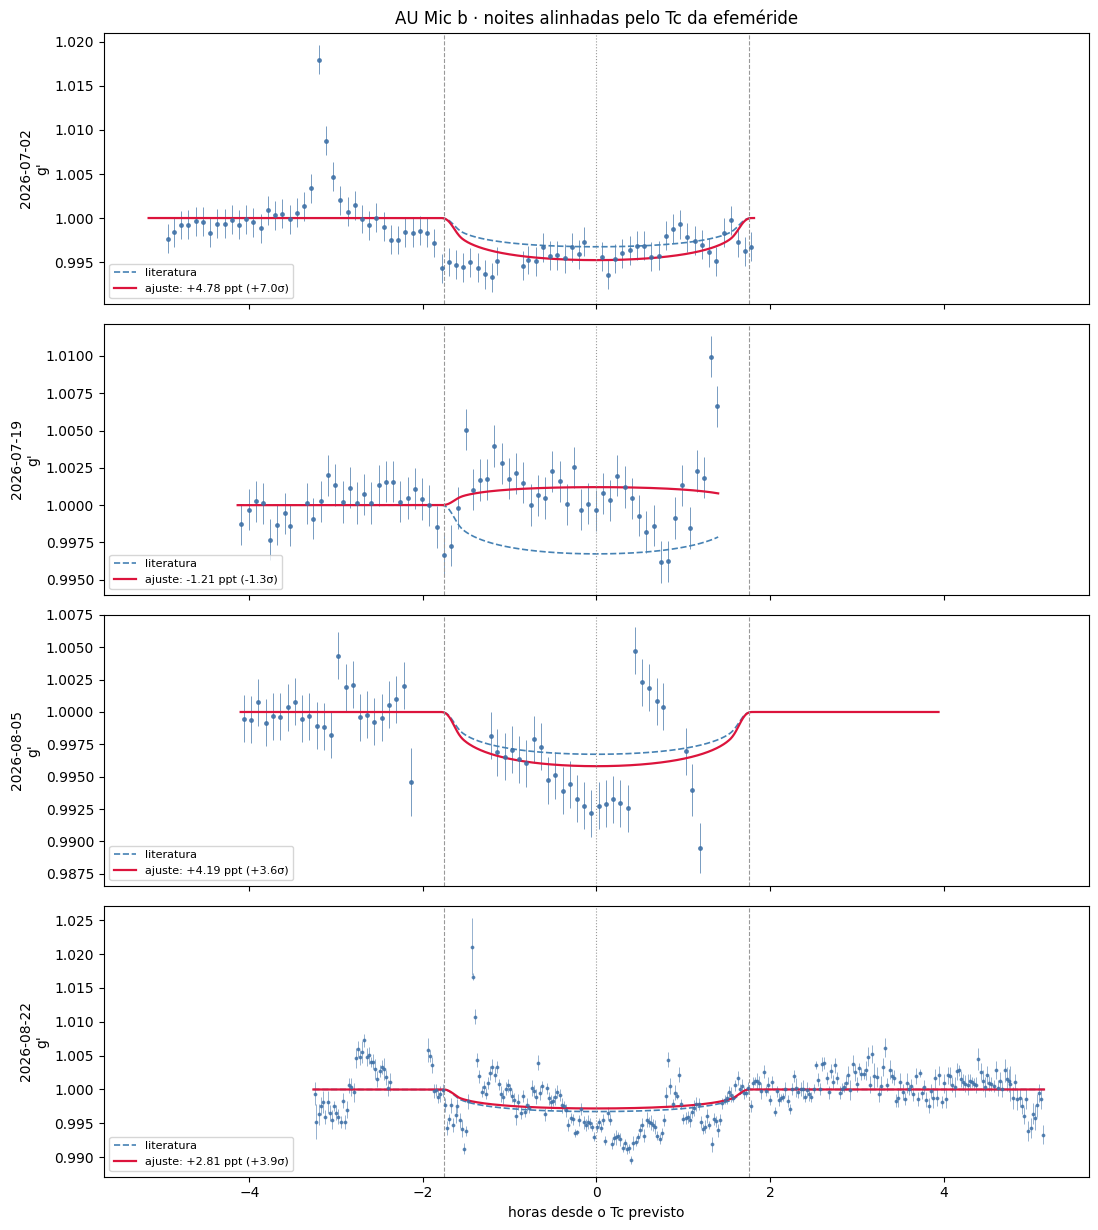

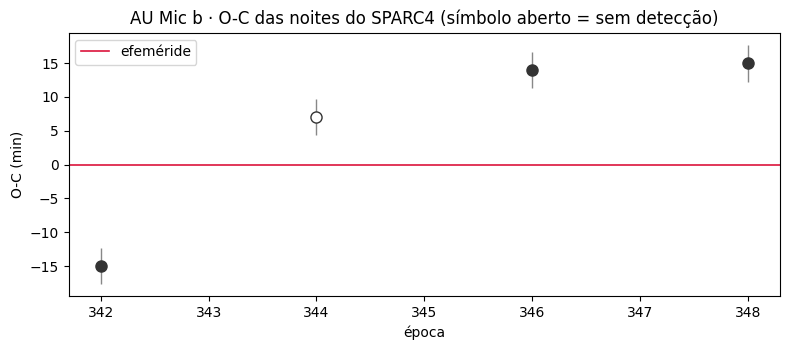

O O-C acima é diagnóstico, não medida: onde a profundidade sai negativa ou compatível
com zero, o ajuste não está seguindo trânsito nenhum.


In [11]:
# ═══ 11 · as noites lado a lado ═════════════════════════════════════════════
ordenadas = sorted(fixos.values(), key=lambda r: r["epoca"])
plota_noites(ordenadas)
plota_oc(sorted(resultados.values(), key=lambda r: r["epoca"]))
print("O O-C acima é diagnóstico, não medida: onde a profundidade sai negativa "
      "ou compatível\ncom zero, o ajuste não está seguindo trânsito nenhum.")

In [26]:
# ═══ 12 · arquivos gravados ═════════════════════════════════════════════════
# Curvas + linha de base de cada noite, as duas tabelas e um resumo em texto.

def salva_curvas(r, prefixo):
    """Grava a curva de cada banda com a linha de base ajustada.

    Nas noites ajustadas na cadência original grava-se a versão binada em
    BIN_VIS_MIN — a mesma das figuras. São dezenas de milhares de pontos por
    banda, e o ajuste é reproduzível a partir do notebook de qualquer forma.
    """
    caminho = prefixo + "_curvas.csv"
    tabelas = []
    for ch in r["canais"]:
        t, f, e, base, _ = pontos_figura(r, ch)
        tabelas.append(pd.DataFrame({
            "banda": r["dados"][ch]["banda"], "bjd_tdb": t, "fluxo": f, "erro": e,
            "base": base, "fluxo_corrigido": f / base}))
    pd.concat(tabelas).to_csv(caminho, index=False)
    return caminho


def txt(tabela):
    return tabela.to_string(float_format=lambda v: f"{v:.2f}")


gravados = []
for noite, r in fixos.items():
    pref = os.path.join(OUTDIR, f"aumic_b_{noite}_ep{r['epoca']}")
    gravados.append(salva_curvas(r, pref))
    r["tab_bandas"].round(3).to_csv(pref + "_bandas.csv")
    gravados.append(pref + "_bandas.csv")

for nome, tabela in [("aumic_b_noites_tc_livre.csv", TAB_LIVRE),
                     ("aumic_b_noites_tc_fixo.csv", TAB_FIXO)]:
    tabela.round(3).to_csv(os.path.join(OUTDIR, nome))
    gravados.append(os.path.join(OUTDIR, nome))

resumo_txt = os.path.join(OUTDIR, "aumic_b_resumo.txt")
with open(resumo_txt, "w", encoding="utf-8") as fh:
    fh.write(f"AU Mic b · SPARC4 · AP{APER:03d} · feixe {BEAM} · "
             f"{NCOMPS} comparações\n")
    fh.write(f"efeméride T0={T0_TDB} P={PER} | T14={T14*24:.3f} h | b={B_IMP:.3f}\n")
    fh.write(f"noites: {', '.join(rotulo_noite(n) for n in NOITES_TRANSITO)}\n\n")
    fh.write("Tc livre (diagnóstico — o instante não é mensurável nestas noites)\n")
    fh.write(txt(TAB_LIVRE) + "\n\n")
    fh.write("Tc preso na efeméride (a medida)\n" + txt(TAB_FIXO) + "\n\n")
    for r in fixos.values():
        fh.write(f"{r['rotulo']} · banda a banda\n"
                 + txt(r["tab_bandas"]) + "\n\n")
    fh.write(f"média ponderada em {list(fixos.values())[0]['bandas'][0]}': "
             f"{prof_med:+.2f} +- {sig_med:.2f} ppt "
             f"(literatura {esperada:.2f} ppt)\n")
gravados.append(resumo_txt)

print("gravado em", OUTDIR, "\n")
for g in gravados:
    print(f"   {os.path.basename(g):<40s} {os.path.getsize(g)/1024:8.1f} kB")

gravado em C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\resultados_transitos 

   aumic_b_20260702_ep342_curvas.csv            30.8 kB
   aumic_b_20260702_ep342_bandas.csv             0.2 kB
   aumic_b_20260719_ep344_curvas.csv            25.6 kB
   aumic_b_20260719_ep344_bandas.csv             0.2 kB
   aumic_b_20260805_ep346_curvas.csv            20.9 kB
   aumic_b_20260805_ep346_bandas.csv             0.2 kB
   aumic_b_20260822_ep348_curvas.csv           125.1 kB
   aumic_b_20260822_ep348_bandas.csv             0.2 kB
   aumic_b_noites_tc_livre.csv                   0.4 kB
   aumic_b_noites_tc_fixo.csv                    0.4 kB
   aumic_b_resumo.txt                            3.9 kB
